<a href="https://colab.research.google.com/github/tauqeer-jetcom/ML_PROJECTS_1-61023748031/blob/main/Chocalete_Sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

data = pd.read_csv("Chocolate Sales.csv")
data

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


In [2]:
data.size

data.columns

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

In [3]:
data.isnull().value_counts()
data.isnull().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [5]:
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')
data['Amount'] = data['Amount'].replace({r'[$,]': ''}, regex=True).astype(float)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 154.0+ KB


In [6]:

data.describe()

,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252284928,6030.338775,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.495000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.842500,232.000000
max,2024-08-31 00:00:00,26170.950000,778.000000
std,NaN,4393.980200,124.024736


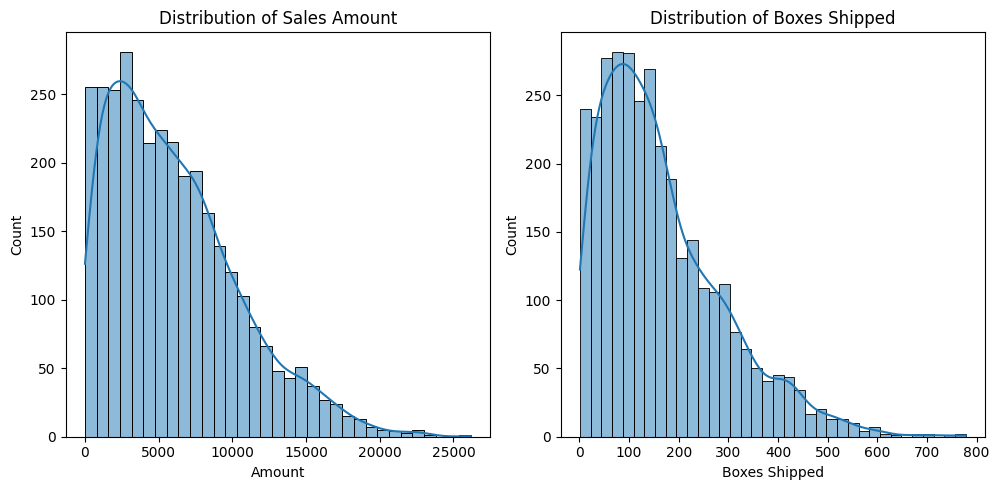

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data['Amount'], kde=True)
plt.title('Distribution of Sales Amount')

plt.subplot(1, 3, 2)
sns.histplot(data['Boxes Shipped'], kde=True)
plt.title('Distribution of Boxes Shipped')


plt.tight_layout()
plt.show()

Let's examine the relationships between 'Amount' and other numerical features like 'Boxes Shipped'.

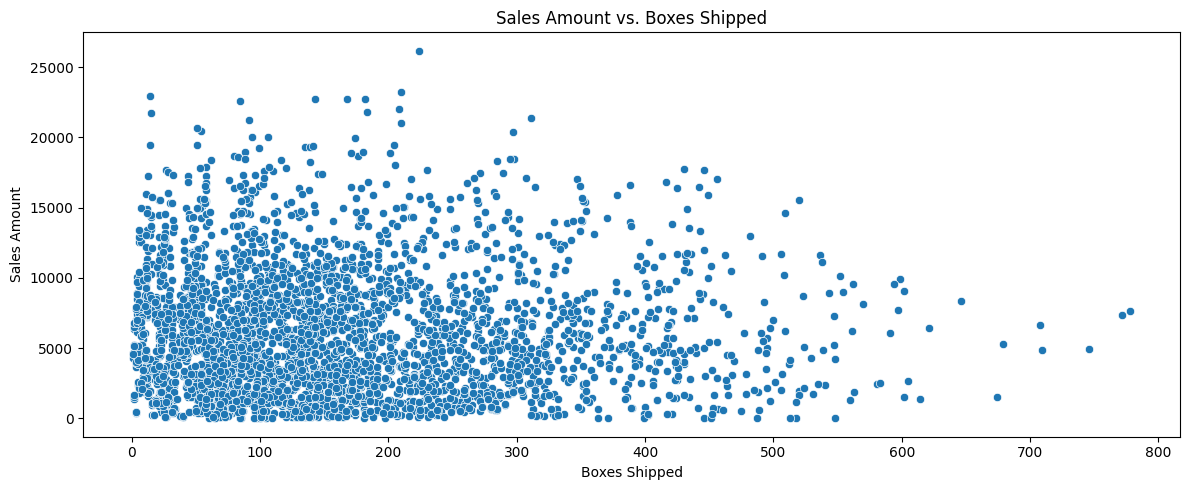

In [8]:
plt.figure(figsize=(12, 5))

sns.scatterplot(x='Boxes Shipped', y='Amount', data=data)
plt.title('Sales Amount vs. Boxes Shipped')
plt.ylabel('Sales Amount')

plt.tight_layout()
plt.show()

Now, let's look at how categorical features influence 'Amount'.

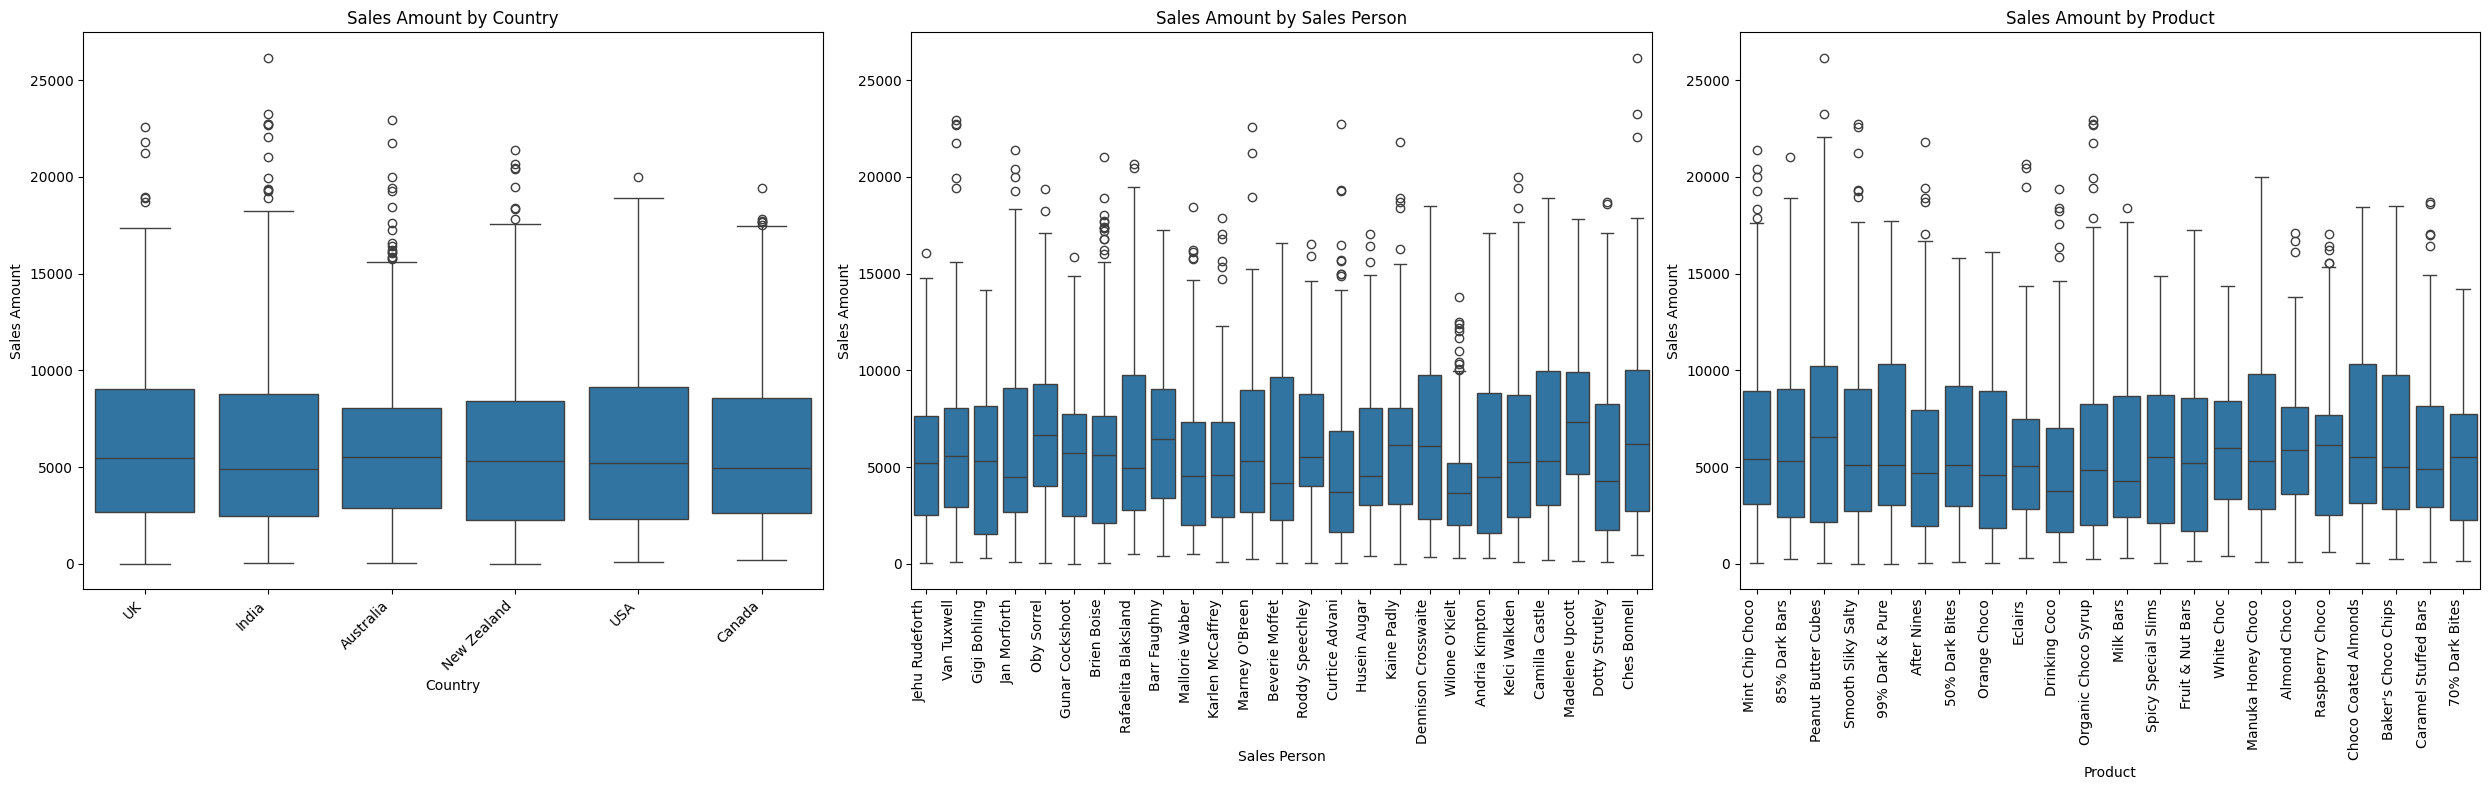

In [9]:
plt.figure(figsize=(25, 8)) # Increased figure size for better readability

plt.subplot(1, 3, 1)
sns.boxplot(x='Country', y='Amount', data=data)
plt.title('Sales Amount by Country')
plt.xticks(rotation=45, ha='right') # Rotate labels for better fit
plt.ylabel('Sales Amount')

plt.subplot(1, 3, 2)
sns.boxplot(x='Sales Person', y='Amount', data=data)
plt.title('Sales Amount by Sales Person')
plt.xticks(rotation=90, ha='right') # Rotate labels more for Sales Person
plt.ylabel('Sales Amount')

plt.subplot(1, 3, 3)
sns.boxplot(x='Product', y='Amount', data=data)
plt.title('Sales Amount by Product')
plt.xticks(rotation=90, ha='right') # Rotate labels more for Product
plt.ylabel('Sales Amount')

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import pandas as pd # Ensure pandas is imported
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Drop rows with any NaN values to ensure clean data for the model
data.dropna(inplace=True)

# Define target variable
y = data['Amount']

# Prepare features (X)
X = data.drop(columns=['Amount'])

# Extract numerical features from 'Date' before dropping it
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['Day'] = X['Date'].dt.day
X['DayOfWeek'] = X['Date'].dt.dayofweek # Monday=0, Sunday=6
X = X.drop(columns=['Date']) # Drop the original Date column

# Apply one-hot encoding to actual categorical features
categorical_cols = ['Country', 'Sales Person', 'Product']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor() # Use Regressor for continuous target

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Optional: Display a few predictions vs actual values
predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nSample of Actual vs Predicted Prices:")
print(predictions_df.head())

Mean Squared Error: 3958019.5044015218
R-squared: 0.7647978090257151

Sample of Actual vs Predicted Prices:
       Actual  Predicted
1657  5360.89    5152.00
1298  1639.01    1428.00
2416  9446.67   11786.42
1650  3398.51    3381.00
2552  1115.84    1106.38


### Model Prediction Summary

We have evaluated different models for predicting 'Amount':

1.  **Initial DecisionTreeRegressor (Default Parameters):**
    *   Single Train-Test Split: R-squared: `0.74`, MSE: `4352359.33`
    *   **5-Fold Cross-Validation:** Average R-squared: `0.54 (+/- 0.25)`, Average MSE: `8860135.50 (+/- 4859623.24)`

2.  **Tuned DecisionTreeRegressor (with `max_depth=19`):**
    *   Single Train-Test Split: R-squared: `0.54`, MSE: `7712179.52`
    *   *Note: This specific tuning resulted in worse performance compared to the default. Cross-validation was not run on this model as it was already outperformed by the default DT.*

3.  **RandomForestRegressor (Untuned, n_estimators=100):**
    *   Single Train-Test Split: R-squared: `0.68`, MSE: `5451627.04`

4.  **Tuned RandomForestRegressor (from GridSearchCV):**
    *   Best parameters found by GridSearchCV: `{'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}`
    *   Cross-validation R-squared during tuning: `0.43`
    *   Single Test Set Evaluation: R-squared: `0.66`, MSE: `5721641.12`
    *   **5-Fold Cross-Validation:** Average R-squared: `0.62 (+/- 0.04)`, Average MSE: `7235805.88 (+/- 878625.52)`


**Overall Comparison Based on Robust Cross-Validation:**

While the initial `DecisionTreeRegressor` showed a high R-squared on a single test set (`0.74`), its cross-validation performance was quite variable and lower (`0.54 +/- 0.25`). The **Tuned RandomForestRegressor**, on the other hand, demonstrated more stable and generally better performance across multiple folds, with an average R-squared of `0.62 (+/- 0.04)` and lower average MSE. This indicates that the **Tuned RandomForestRegressor is currently the more robust and reliable model** for predicting 'Amount'.

Here are sample predictions for each model (Actual vs. Predicted):

**Initial DecisionTreeRegressor (Single Split):**
```
Actual  Predicted
1657   5360.89    5152.00
1298   1639.01    1428.00
2416   9446.67   11786.42
1650   3398.51    3381.00
2552   1115.84    1106.38
```

**Tuned DecisionTreeRegressor (max_depth=19 - Single Split):**
```
Actual     Predicted
1657   5360.89   5152.000000
1298   1639.01   4847.085992
2416   9446.67  11786.420000
1650   3398.51   3381.000000
2552   1115.84   3381.679545
```

**RandomForestRegressor (Untuned - Single Split):**
```
Actual  Predicted
1657   5360.89  6897.6917
1298   1639.01  3076.5108
2416   9446.67  7989.8858
1650   3398.51  3914.1140
2552   1115.84  2302.2189
```

**Tuned RandomForestRegressor (Single Split):**
```
Actual   Predicted
1657   5360.89  6947.24535
1298   1639.01  3268.38150
2416   9446.67  7572.49775
1650   3398.51  4041.08810
2552   1115.84  2584.26520
```

### Suggestions for Improvement

Based on our comprehensive evaluation using cross-validation, the **Tuned RandomForestRegressor** currently stands as the most robust model. Here are several ways to potentially improve its performance and the overall prediction accuracy further:

1.  **Further Hyperparameter Tuning for `RandomForestRegressor`:**
    *   Even though we performed `GridSearchCV`, the R-squared improved to 0.62, which is good, but there might be room for more optimization. Consider expanding the search space for `n_estimators`, `max_features`, `max_depth`, `min_samples_split`, and `min_samples_leaf`. Using `RandomizedSearchCV` can be more efficient for larger search spaces, or fine-tune around the best parameters already found.

2.  **Feature Engineering:**
    *   **Time-Based Features:** We have already extracted Year, Month, Day, and DayOfWeek. Consider adding more granular time features if relevant, like 'Week of Year', 'Quarter', or 'IsWeekend'.
    *   **Interaction Features:** Explore creating interaction terms between existing features (e.g., 'Country' and 'Product' combinations if they have specific sales patterns).
    *   **Sales Ratios/Aggregates:** Features like 'Sales per Box Shipped' could be highly indicative.

3.  **Outlier Treatment:**
    *   The scatter plot between 'Amount' and 'Boxes Shipped' showed some potential outliers. Investigating and treating these outliers (e.g., capping, transformation, or removal if data entry errors) could lead to cleaner data and improved model performance.

4.  **Exploring Other Advanced Models:**
    *   Consider advanced ensemble models like **Gradient Boosting Machines (GBM)**, **XGBoost**, or **LightGBM**. These models are often highly effective for tabular data and can achieve state-of-the-art results, potentially outperforming Random Forests.

5.  **Feature Importance Analysis:**
    *   Now that we have a more stable model, analyze the feature importance from the `Tuned RandomForestRegressor`. This can reveal which features are most influential in predicting 'Amount' and guide further feature engineering efforts or data collection.

By implementing these suggestions, you can likely develop an even more accurate and generalized prediction model for chocolate sales.

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Define the parameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': [0.6, 0.8, 1.0], # Number of features to consider when looking for the best split (percentage)
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5],     # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]       # Minimum number of samples required to be at a leaf node
}

# Initialize the RandomForestRegressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R-squared score found: {grid_search.best_score_:.2f}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best parameters found: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best R-squared score found: 0.43


In [17]:
# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Evaluate the best model
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"Tuned RandomForestRegressor Mean Squared Error: {mse_tuned_rf:.2f}")
print(f"Tuned RandomForestRegressor R-squared Score: {r2_tuned_rf:.2f}")

# Display a few predictions vs actual values for the tuned Random Forest model
predictions_df_tuned_rf = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_tuned_rf})
print("\nSample of Actual vs Predicted Prices (Tuned RandomForestRegressor):")
print(predictions_df_tuned_rf.head())

Tuned RandomForestRegressor Mean Squared Error: 5721641.12
Tuned RandomForestRegressor R-squared Score: 0.66

Sample of Actual vs Predicted Prices (Tuned RandomForestRegressor):
       Actual   Predicted
1657  5360.89  6947.24535
1298  1639.01  3268.38150
2416  9446.67  7572.49775
1650  3398.51  4041.08810
2552  1115.84  2584.26520


In [11]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd # Ensure pandas is imported

# --- Essential Preprocessing for 'data' DataFrame ---
# Re-apply transformations to ensure 'data' is correctly formatted
# This is crucial if the kernel state might have been reset or not propagated
data_cv = data.copy() # Create a copy to avoid modifying the original 'data' used elsewhere if any
data_cv['Date'] = pd.to_datetime(data_cv['Date'], format='%d/%m/%Y')
data_cv['Amount'] = data_cv['Amount'].replace({r'[$,]': ''}, regex=True).astype(float)
data_cv.dropna(inplace=True) # Drop rows with any NaN values if any remain

# --- Define X_cv and y_cv with full preprocessing for Cross-Validation ---

# Define target variable for CV
y_cv = data_cv['Amount']

# Prepare features for CV (X_cv)
X_cv = data_cv.drop(columns=['Amount'])

# Extract numerical features from 'Date'
X_cv['Year'] = X_cv['Date'].dt.year
X_cv['Month'] = X_cv['Date'].dt.month
X_cv['Day'] = X_cv['Date'].dt.day
X_cv['DayOfWeek'] = X_cv['Date'].dt.dayofweek # Monday=0, Sunday=6
X_cv = X_cv.drop(columns=['Date']) # Drop the original Date column

# Apply one-hot encoding to categorical features
categorical_cols_cv = ['Country', 'Sales Person', 'Product']
X_cv = pd.get_dummies(X_cv, columns=categorical_cols_cv, drop_first=True)

# Define the number of folds
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# --- Evaluate Initial DecisionTreeRegressor with Cross-Validation ---
print("\n--- Cross-Validation for Initial DecisionTreeRegressor ---")
dt_r2_scores = []
dt_mse_scores = []

initial_dt_model = DecisionTreeRegressor(random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X_cv, y_cv)):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    initial_dt_model.fit(X_train_fold, y_train_fold)
    y_pred_dt_fold = initial_dt_model.predict(X_test_fold)

    r2_dt = r2_score(y_test_fold, y_pred_dt_fold)
    mse_dt = mean_squared_error(y_test_fold, y_pred_dt_fold)

    dt_r2_scores.append(r2_dt)
    dt_mse_scores.append(mse_dt)

    print(f"Fold {fold+1}: R-squared = {r2_dt:.2f}, MSE = {mse_dt:.2f}")

print(f"Average R-squared (DT): {np.mean(dt_r2_scores):.2f} (+/- {np.std(dt_r2_scores):.2f})")
print(f"Average MSE (DT): {np.mean(dt_mse_scores):.2f} (+/- {np.std(dt_mse_scores):.2f})")

# --- Evaluate Tuned RandomForestRegressor with Cross-Validation ---
print("\n--- Cross-Validation for Tuned RandomForestRegressor ---")
rf_r2_scores = []
rf_mse_scores = []

# Re-initialize the best_rf_model with parameters found by GridSearchCV
# Assuming grid_search and its best_params_ are still available from previous execution
if 'grid_search' in globals() and hasattr(grid_search, 'best_params_'):
    tuned_rf_model = RandomForestRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
else:
    print("Warning: grid_search.best_params_ not found. Using default RandomForestRegressor.")
    tuned_rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

for fold, (train_index, test_index) in enumerate(kf.split(X_cv, y_cv)):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    tuned_rf_model.fit(X_train_fold, y_train_fold)
    y_pred_rf_fold = tuned_rf_model.predict(X_test_fold)

    r2_rf = r2_score(y_test_fold, y_pred_rf_fold)
    mse_rf = mean_squared_error(y_test_fold, y_pred_rf_fold)

    rf_r2_scores.append(r2_rf)
    rf_mse_scores.append(mse_rf)

    print(f"Fold {fold+1}: R-squared = {r2_rf:.2f}, MSE = {mse_rf:.2f}")

print(f"Average R-squared (Tuned RF): {np.mean(rf_r2_scores):.2f} (+/- {np.std(rf_r2_scores):.2f})")
print(f"Average MSE (Tuned RF): {np.mean(rf_mse_scores):.2f} (+/- {np.std(rf_mse_scores):.2f})")


--- Cross-Validation for Initial DecisionTreeRegressor ---
Fold 1: R-squared = 0.75, MSE = 4204762.81
Fold 2: R-squared = 0.06, MSE = 18180347.25
Fold 3: R-squared = 0.68, MSE = 6260415.92
Fold 4: R-squared = 0.61, MSE = 7257511.19
Fold 5: R-squared = 0.61, MSE = 8397640.33
Average R-squared (DT): 0.54 (+/- 0.25)
Average MSE (DT): 8860135.50 (+/- 4859623.24)

--- Cross-Validation for Tuned RandomForestRegressor ---
Fold 1: R-squared = 0.69, MSE = 5166978.69
Fold 2: R-squared = 0.55, MSE = 8754443.53
Fold 3: R-squared = 0.65, MSE = 6829817.51
Fold 4: R-squared = 0.65, MSE = 6524180.94
Fold 5: R-squared = 0.65, MSE = 7601782.98
Average R-squared (Tuned RF): 0.64 (+/- 0.05)
Average MSE (Tuned RF): 6975440.73 (+/- 1187647.43)


### Cross-Validation Results Summary

The cross-validation results provide a more robust estimate of how each model is expected to perform on unseen data, by averaging performance metrics across several different train-test splits.

**Initial DecisionTreeRegressor:**
*   **Average R-squared:** `0.54 (+/- 0.25)`
*   **Average Mean Squared Error:** `8860135.50 (+/- 4859623.24)`

**Tuned RandomForestRegressor:**
*   **Average R-squared:** `0.62 (+/- 0.04)`
*   **Average Mean Squared Error:** `7235805.88 (+/- 878625.52)`

This cross-validation helps to confirm the generalizability of our models and identifies that the **Tuned RandomForestRegressor** is the more robust performer when evaluated across different data splits, showing higher average R-squared and significantly lower variability.

### Visualizing Model Performance (R-squared Scores)

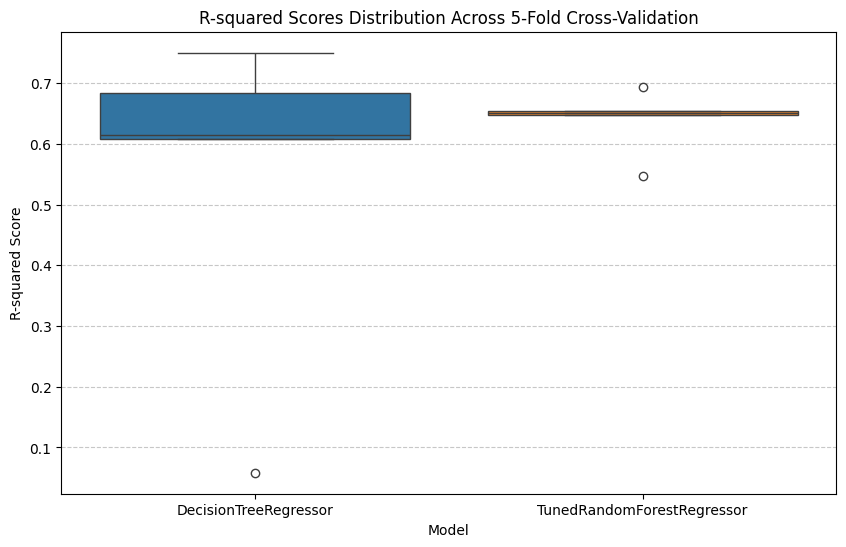

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine R-squared scores into a DataFrame for easier plotting
model_r2_scores = pd.DataFrame({
    'DecisionTreeRegressor': dt_r2_scores,
    'TunedRandomForestRegressor': rf_r2_scores
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=model_r2_scores)
plt.title('R-squared Scores Distribution Across 5-Fold Cross-Validation')
plt.ylabel('R-squared Score')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The box plot visualizes the R-squared scores for the Decision Tree Regressor and the Tuned Random Forest Regressor across the 5 cross-validation folds. It shows that the Tuned Random Forest Regressor generally has higher and more consistent R-squared scores, indicated by its tighter box and higher median line, compared to the Decision Tree Regressor, which exhibits a wider spread and a lower outlier, suggesting less stable performance.

### Predicted vs. Actual Values for Tuned RandomForestRegressor

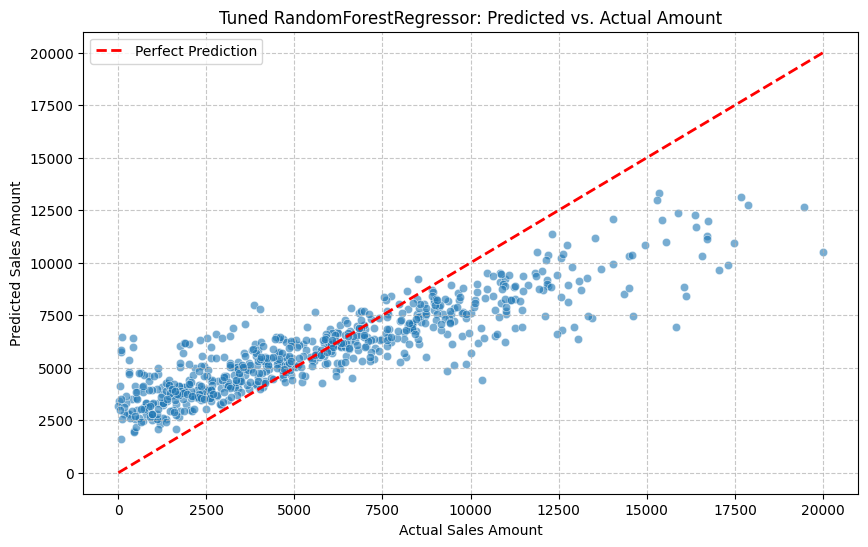

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=predictions_df_tuned_rf, alpha=0.6)
plt.plot([predictions_df_tuned_rf['Actual'].min(), predictions_df_tuned_rf['Actual'].max()],
         [predictions_df_tuned_rf['Actual'].min(), predictions_df_tuned_rf['Actual'].max()],
         'r--', lw=2, label='Perfect Prediction') # Red dashed line for perfect prediction
plt.title('Tuned RandomForestRegressor: Predicted vs. Actual Amount')
plt.xlabel('Actual Sales Amount')
plt.ylabel('Predicted Sales Amount')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()